# Variable Importance Measures Comparison

We have presented the coefficients of a linear model, Permutation Feature Importance (PFI), Conditional Feature Importance (CFI), and Leave-One-Covariate-Out (LOCO). How can we relate all of these quantities?

We focus on a linear setting, where a linear model is sufficient to understand the underlying data-generating process.

We have shown that Conditional Feature Importance is equal to twice LOCO. Therefore, we can rescale CFI by dividing it by 2 to match the LOCO scale.

We proceed similarly for PFI, even though the underlying estimand is not necessarily the same. Is it measuring the same quantity in this setting?

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np

seed = 0


def random_covariance(p, strength=0.5, seed=None):
    rng = np.random.default_rng(seed)

    # random matrix
    A = rng.normal(size=(p, p))

    # make it symmetric PSD-like
    Sigma = A @ A.T

    # normalize to correlation matrix
    D = np.sqrt(np.diag(Sigma))
    Sigma = Sigma / np.outer(D, D)

    # shrink toward identity (controls correlation strength)
    Sigma = strength * Sigma + (1 - strength) * np.eye(p)

    return Sigma


def linear_data(n, p, correlation=0.25, sparsity=0.5, seed=None):
    """Function to simulate linear data with an autoregressive structure with Toeplitz
    covariance matrix
    """
    # Setup seed generator
    rng = np.random.default_rng(seed)

    # Number of non-null
    k = int(sparsity * p)

    # Generate the variables from a multivariate normal distribution
    mu = np.zeros(p)
    Sigma = np.array(
        [[(correlation) ** abs(i - j) for i in range(p)] for j in range(p)]
    )  # covariance matrix of X
    Sigma = random_covariance(p, strength=correlation, seed=seed)
    X = rng.multivariate_normal(mu, Sigma, size=(n))
    # Generate the response from a linear model
    non_zero = rng.choice(p, k, replace=False)
    beta_true = np.zeros(p)
    beta_true[non_zero] = 1.0
    eps = rng.standard_normal(size=n)
    y = np.dot(X, beta_true) + eps

    return X, y, beta_true

/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
X, y, beta = linear_data(1000, 10, correlation=0, sparsity=0.5, seed=seed)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
)

In [3]:
import pandas as pd
from sklearn.linear_model import RidgeCV
from hidimstat import LOCO, CFI, PFI


model = RidgeCV()
df_list = []

# Train the model
model = model.fit(X_train, y_train)

# COEFFICIENT importance is computed by taking the square of the coefficients of the linear

df_list.append(
    pd.DataFrame(
        {
            "VIM": "Coefficient",
            "feature": list(range(X.shape[1])),
            "importance": model.coef_**2,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)

# Permutation Feature Importance (PFI)
pfi = PFI(model)
# For each feature, compute the feature importance by measuring the change in model
# performance when the feature is marginally permuted. This process is repeated for
# all features to evaluate their importance.
pfi.fit(X_train, y_train)
importances = 0.5 * pfi.importance(X_test, y_test)
df_list.append(
    pd.DataFrame(
        {
            "VIM": "PFI",
            "feature": list(range(X.shape[1])),
            "importance": importances,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)

loco = LOCO(model)
# For each feature, remove it from the dataset, refit the model, and compute LOCO
# importance. This process is repeated for all features to assess their individual
# contributions.
loco.fit(X_train, y_train)
importances = loco.importance(X_test, y_test)
df_list.append(
    pd.DataFrame(
        {
            "VIM": "LOCO",
            "feature": list(range(X.shape[1])),
            "importance": importances,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)
cfi = CFI(model)
# For each feature, compute the feature importance by measuring the change in model
# performance when the feature is conditionally permuted. This process is repeated for
# all features to evaluate their importance.
cfi.fit(X_train, y_train)
importances = 0.5 * cfi.importance(X_test, y_test)
df_list.append(
    pd.DataFrame(
        {
            "VIM": "CFI",
            "feature": list(range(X.shape[1])),
            "importance": importances,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)
df_plot = pd.concat(df_list)

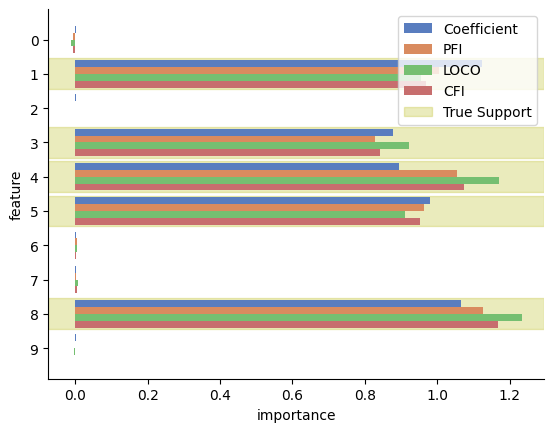

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.barplot(
    data=df_plot,
    y="feature",
    x="importance",
    hue="VIM",
    palette="muted",
    orient="h",
)
sns.despine()

for i, support in enumerate(beta):
    if support != 0:
        ax.axhspan(
            i - 0.45,
            i + 0.45,
            color="tab:olive",
            alpha=0.3,
            zorder=-1,
            label="True Support" if i == 1 else None,
        )
ax.legend()
plt.show()

We observe that all these Variable Importance Measures are very close and appear to target the same underlying quantity. Is this always the case?

Why, in this setting, does Permutation Feature Importance (PFI) coincide with Conditional Feature Importance (CFI)?

## Increasing the Correlation

What happens if we increase the correlation between features? How does this affect Conditional Feature Importance (CFI), and how does it change the estimated coefficients?

In [5]:
X, y, beta = linear_data(10000, 10, correlation=0.6, sparsity=0.5, seed=seed)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
)

In [6]:
model = RidgeCV()
df_list = []

model = model.fit(X_train, y_train)

df_list.append(
    pd.DataFrame(
        {
            "VIM": "Coefficient",
            "feature": list(range(X.shape[1])),
            "importance": model.coef_**2,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)

pfi = PFI(model)
# For each feature, compute the feature importance by measuring the change in model
# performance when the feature is marginally permuted. This process is repeated for
# all features to evaluate their importance.
pfi.fit(X_train, y_train)
importances = 0.5 * pfi.importance(X_test, y_test)
df_list.append(
    pd.DataFrame(
        {
            "VIM": "PFI",
            "feature": list(range(X.shape[1])),
            "importance": importances,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)

loco = LOCO(model)
# For each feature, remove it from the dataset, refit the model, and compute LOCO
# importance. This process is repeated for all features to assess their individual
# contributions.
loco.fit(X_train, y_train)
importances = loco.importance(X_test, y_test)
df_list.append(
    pd.DataFrame(
        {
            "VIM": "LOCO",
            "feature": list(range(X.shape[1])),
            "importance": importances,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)
cfi = CFI(model)
# For each feature, compute the feature importance by measuring the change in model
# performance when the feature is conditionally permuted. This process is repeated for
# all features to evaluate their importance.
cfi.fit(X_train, y_train)
importances = 0.5 * cfi.importance(X_test, y_test)
df_list.append(
    pd.DataFrame(
        {
            "VIM": "CFI",
            "feature": list(range(X.shape[1])),
            "importance": importances,
            "model": model.__class__.__name__,
            "R2 score": model.score(X_test, y_test),
        }
    )
)

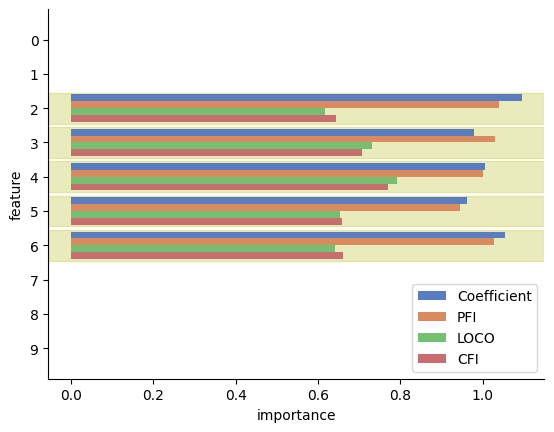

In [7]:
df_plot = pd.concat(df_list)


ax = sns.barplot(
    data=df_plot,
    y="feature",
    x="importance",
    hue="VIM",
    palette="muted",
    orient="h",
)
sns.despine()

for i, support in enumerate(beta):
    if support != 0:
        ax.axhspan(
            i - 0.45,
            i + 0.45,
            color="tab:olive",
            alpha=0.3,
            zorder=-1,
            label="True Support" if i == 1 else None,
        )
ax.legend()
plt.show()

What can we conclude from this? What happens as the correlation between features increases?